# Эксперимент 02: Random Forest на MFCC

**Статья:** Методы и алгоритмы распознавания речи с дефектными произношениями 2020

**Ссылка:** [https://cyberleninka.ru/article/n/metody-i-algoritmy-raspoznavaniya-rechi-s-defektnymi-proiznosheniyami](https://cyberleninka.ru/article/n/metody-i-algoritmy-raspoznavaniya-rechi-s-defektnymi-proiznosheniyami)

**Краткое описание модели:** MFCC-статистики + признаки букв -> Random Forest с подбором параметров по F1-macro.

In [3]:
import sys
from pathlib import Path
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    classification_report,
)
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))

from shared import config, data_utils
from shared.results_utils import save_result_csv

## 1. Загрузка разбиений и извлечение признаков

In [4]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")

def extract(path):
    return data_utils.extract_mfcc_stats(path)

X_train = data_utils.build_feature_matrix(paths_train, extract, n_jobs=-1)
X_val   = data_utils.build_feature_matrix(paths_val,   extract, n_jobs=-1)
X_test  = data_utils.build_feature_matrix(paths_test,  extract, n_jobs=-1)

X_train = np.hstack([X_train, letters_train])
X_val   = np.hstack([X_val, letters_val])
X_test  = np.hstack([X_test, letters_test])

print(f"Признаков на объект: {X_train.shape[1]}")

Train: 1942, Val: 417, Test: 417
Признаков на объект: 88


## 2. Масштабирование, подбор гиперпараметров и обучение Random Forest

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

base_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=config.RANDOM_STATE,
    n_jobs=-1,
)

param_grid = {
    "n_estimators": [50, 100, 150, 200, 250, 300, 400],
    "max_depth": [5, 10, 15, 20, 25, 30, None],
    "min_samples_leaf": [1, 2, 3, 4, 5, 8, 10],
}

grid = GridSearchCV(
    base_rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1,
    verbose=1,
)
t0 = time.perf_counter()
grid.fit(X_train_s, y_train)
train_time_sec = time.perf_counter() - t0

print("Лучшие гиперпараметры (по F1-macro на CV):", grid.best_params_)
print("Лучший F1-macro (CV):", f"{grid.best_score_:.4f}")

clf = grid.best_estimator_
print("Обучение завершено.")

Fitting 5 folds for each of 343 candidates, totalling 1715 fits
Лучшие гиперпараметры (по F1-macro на CV): {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 400}
Лучший F1-macro (CV): 0.6694
Обучение завершено.


### Графики: зависимость F1-macro (CV) от гиперпараметров

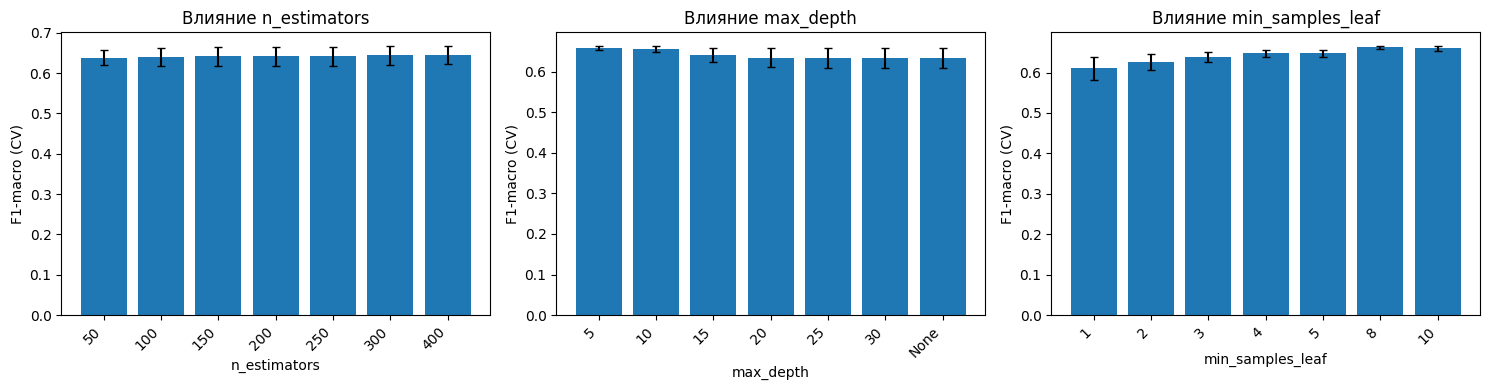

In [6]:
cv_results = grid.cv_results_
param_names = list(param_grid.keys())

fig, axes = plt.subplots(1, len(param_names), figsize=(5 * len(param_names), 4))
if len(param_names) == 1:
    axes = [axes]
for ax, pname in zip(axes, param_names):
    key = "param_" + pname
    vals = list(param_grid[pname])
    scores_mean, scores_std = [], []
    for v in vals:
        mask = cv_results[key] == v
        scores_mean.append(np.mean(cv_results["mean_test_score"][mask]))
        s = np.std(cv_results["mean_test_score"][mask])
        scores_std.append(s if not np.isnan(s) else 0.0)
    x = np.arange(len(vals))
    ax.bar(x, scores_mean, yerr=scores_std, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in vals], rotation=45, ha="right")
    ax.set_xlabel(pname)
    ax.set_ylabel("F1-macro (CV)")
    ax.set_title(f"Влияние {pname}")
plt.tight_layout()
plt.show()

In [7]:
# Важность признаков (топ-10)
imp = clf.feature_importances_
top = np.argsort(imp)[-10:][::-1]
for i in top:
    print(f"  {i}: {imp[i]:.4f}")

  61: 0.0419
  62: 0.0382
  8: 0.0319
  13: 0.0289
  21: 0.0254
  41: 0.0247
  42: 0.0236
  57: 0.0229
  40: 0.0217
  4: 0.0194


## 3. Оценка на тесте и метрики

In [8]:
y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
print("\nТаблица метрик (тест):")
display(metrics_table)

              precision    recall  f1-score   support

        good       0.77      0.87      0.82       282
         bad       0.63      0.47      0.54       135

    accuracy                           0.74       417
   macro avg       0.70      0.67      0.68       417
weighted avg       0.73      0.74      0.73       417

Accuracy: 0.7386
F1 macro: 0.6788
F1 (bad): 0.5401
ROC-AUC:  0.7342

Таблица метрик (тест):


,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.738609,0.678752,0.540084,0.7342,0.627451,0.474074


## 4. Запись метрик в общий файл

In [9]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_mfcc_02_rf",
    experiment_name="Random Forest на MFCC",
    model="Random Forest",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="GridSearchCV " + str(grid.best_params_),
    num_params=None,
    train_time_sec=train_time_sec,
)

PosixPath('/mnt/d/Projects/HSE/VKR/VKR/experiments/exp_02_mfcc_rf/result.csv')